In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    make_classification,
    make_moons,
)

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    classification_report
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC, SVC

In [ ]:
surface_cmap = sns.blend_palette(
    ["#1f2041", "#4b3f72", "#417b5a", "#f4d35e", "#ee964b"], as_cmap=True
)

class_colors = ["#ff6b6b", "#1982c4", "#6a4c93", "#2a9d8f"]

def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid

def score_on_grid(model, grid):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(grid)[:, 1]
    scores = model.decision_function(grid)
    min_score, max_score = scores.min(), scores.max()
    return (scores - min_score) / (max_score - min_score)

def final_estimator(model):
    return model.named_steps["model"] if isinstance(model, Pipeline) else model

def scaler_step(model):
    if isinstance(model, Pipeline):
        return model.named_steps.get("scaler")
    return None

def plot_surface(ax, model, X, y, title, show_support=False, levels=28):
    xx, yy, grid = make_grid(X)
    z = score_on_grid(model, grid).reshape(xx.shape)

    ax.contourf(xx, yy, z, levels=levels, cmap=surface_cmap, alpha=0.94)
    ax.contour(xx, yy, z, levels=[0.5], colors="#fffaf1", linewidths=2.2)
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

##For Logistic Regression, choose the threshold that maximizes recall instead of F1.

In [ ]:
X, y = make_classification(n_samples=500, weights=[0.9, 0.1], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 50)

results = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    recall = recall_score(y_test, y_pred)

    results.append((t, recall))

best_threshold, best_recall = max(results, key=lambda x: x[1])

print("Best threshold:", best_threshold)
print("Best recall:", best_recall)

Best threshold: 0.05
Best recall: 0.9230769230769231


The effect of the classification threshold on the performance of a logistic regression model for imbalanced data was investigated. Instead of the standard threshold value of 0.5, various values in the range from 0.05 to 0.95 was tested with the aim of maximizing the recall metric. It was found that lowering the classification threshold leads to an increase in recall, meaning the model begins to identify a greater number of objects in the rare class. The optimal threshold was selected as the one at which the recall value is maximized.


##On make_moons, try a denser grid of values and watch the boundary overfit.

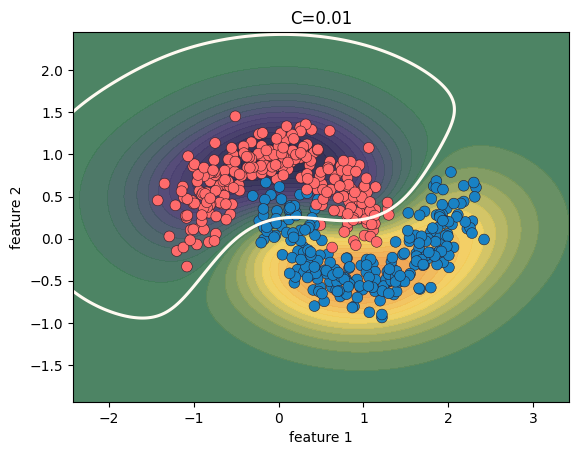

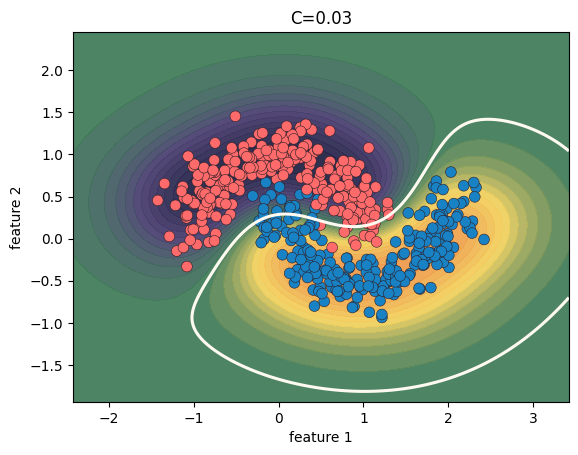

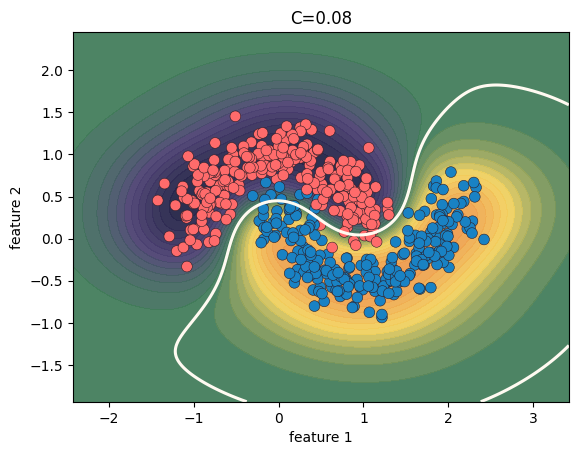

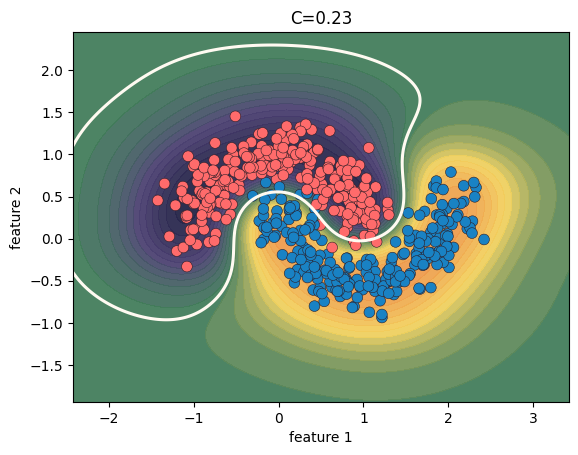

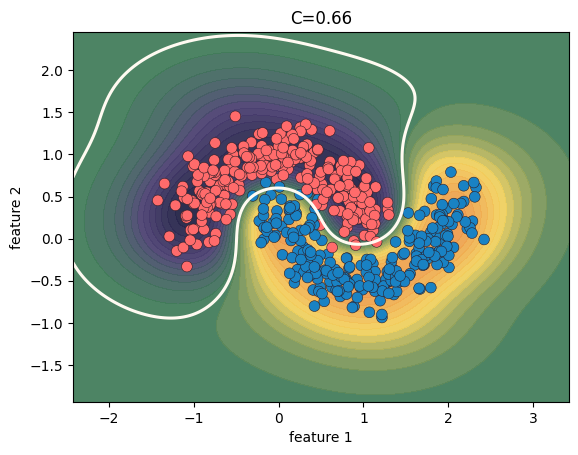

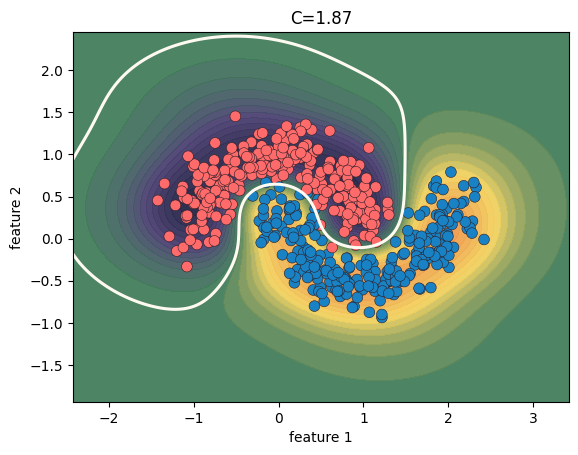

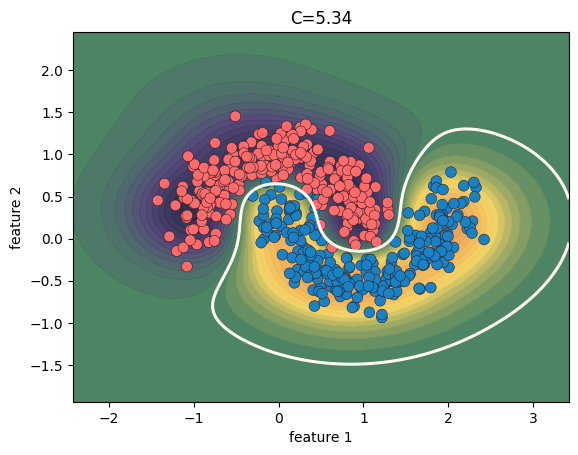

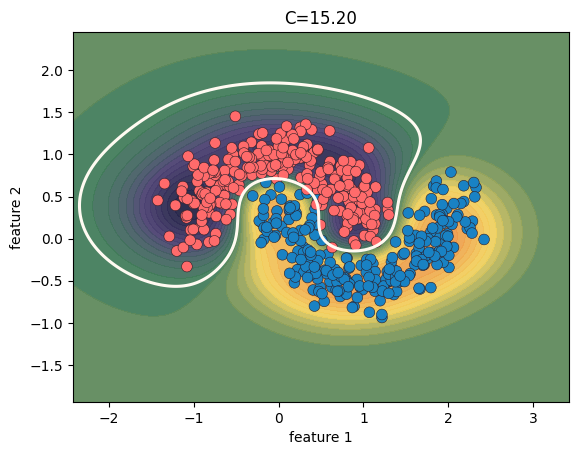

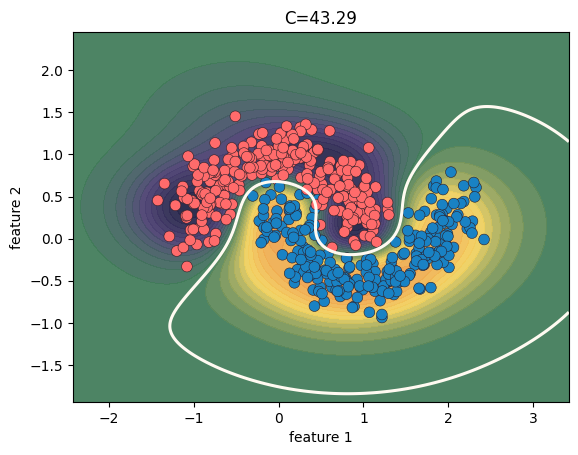

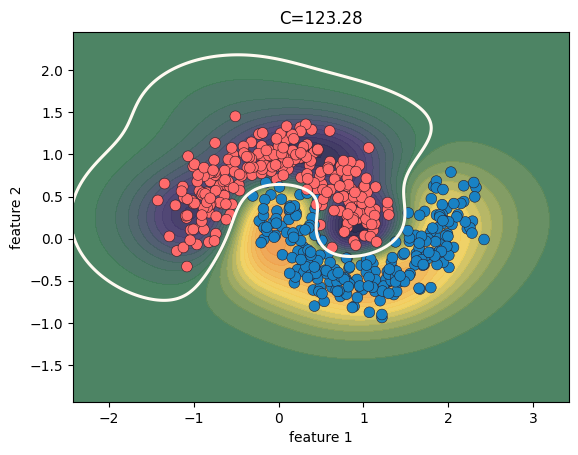

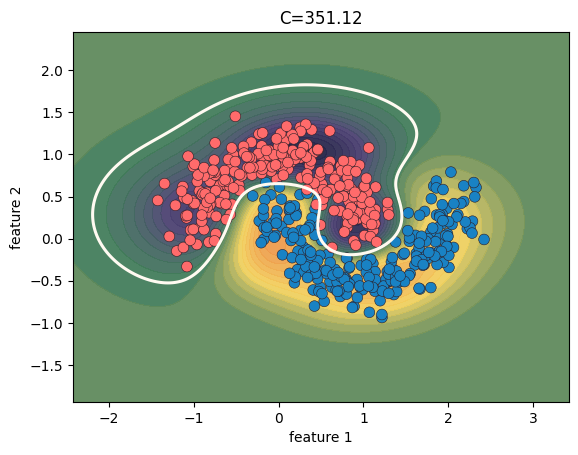

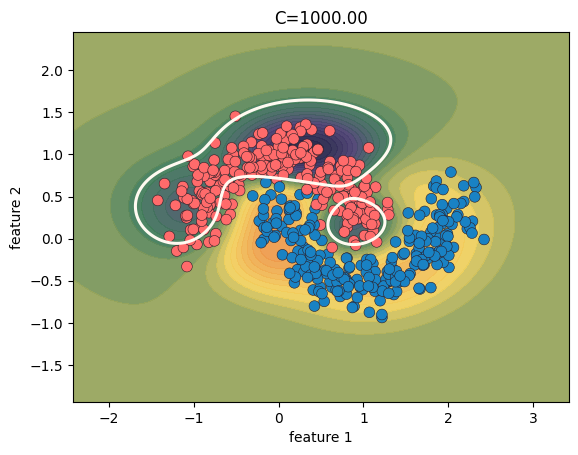

In [ ]:
X, y = make_moons(n_samples = 500, noise = 0.18, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 42)
model = SVC(kernel = 'rbf')
C_values = np.logspace(-2, 3, 12)
gamma_values = np.logspace(-2, 2, 10)

for C in C_values:
  model = Pipeline([("scaler", StandardScaler()),
                    ("model", SVC(kernel = 'rbf', C=C, gamma =1))])

  model.fit(X_train, y_train)
  fig, ax = plt.subplots()
  plot_surface(ax, model, X, y, f"C={C:.2f}")

At low values, the model is underfit, at optimal values, it distinguishes between classes well, and at high values, it overfits, creating a boundary that is too complex. This demonstrates the importance of selecting the right parameters to avoid overfitting.

##Add class_weight="balanced" and test what changes on imbalanced synthetic data.

In [ ]:
X, y = make_classification(n_samples = 500, weights = [0.9, 0.1], random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.25, stratify=y)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(model.score(X_test, y_test))
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

0.936
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       112
           1       1.00      0.38      0.56        13

    accuracy                           0.94       125
   macro avg       0.97      0.69      0.76       125
weighted avg       0.94      0.94      0.92       125



In [ ]:
X, y = make_classification(n_samples = 500, weights = [0.9, 0.1], random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.25, stratify=y)
model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.86      0.91       112
           1       0.41      0.85      0.55        13

    accuracy                           0.86       125
   macro avg       0.69      0.85      0.73       125
weighted avg       0.92      0.86      0.88       125



Adding class_weight="balanced" resulted in a significant improvement in recall for the sparse class, meaning that the model became better at detecting objects in that class. However, this was accompanied by a decrease in precision and overall accuracy, leading to an increase in false positive predictions. This demonstrates a trade-off between precision and full performance with unbalanced data.